# Scan Timestep

In [1]:
from impact import Impact, run_impact_with_distgen
from distgen import Generator

%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt

import numpy as np

import matplotlib
matplotlib.rcParams['figure.figsize'] = (12,8)

In [2]:
# Allows processes to work with macOS
from sys import platform
if platform == 'darwin':
    import multiprocessing as mp
    mp.set_start_method("fork")

# Initial setup and test

In [3]:
G = Generator('$LCLS_LATTICE/distgen/models/cu_inj/distgen.yaml')
G['n_particle']= 10000
G.run()
P0 = G.particles
P0

<ParticleGroup with 10000 particles at 0x1044a97f0>

In [17]:
I0 = Impact.from_yaml('v0/ImpactT.yaml')
I0.stop

16.5

In [19]:
I0 = Impact.from_yaml('v0/ImpactT.yaml')
I0.verbose=True

#I0['change_timestep_1:dt']

I0.total_charge  = 150e-12

I0.stop = 0.4
I0.run()

Removed element: stop_1
Set stop to s = 0.4
Running Impact-T in /var/folders/wj/lfgr01993dx79p9cm_skykbw0000gn/T/tmp298m3tqs
/Users/chrisonian/Code/impact/impactT/bin/ImpactTv2.1_serial
 !-----------------------------------------------------------
 ! IMPACT-T Parallel Beam Dynamics Tracking Code: 2.1 beta version
 ! Copyright of The Regents of the University of California
 !-----------------------------------------------------------
 nblem:           27          27
 pass setting up lattice...
 check randomness:            0  0.30440529327431320     
 avgpts, jlow, and jhigh:        10000           1       10000
 sumx1,sumy1:   -5.4939962563109905E-007   2.0393899752935867E-007
 pass generating initial distribution...
 tstop:   0.40000000000000002     
 i,t,<z>:            1   0.0000000000000000        0.0000000000000000     
 zmin,zmax:    0.0000000000000000       -4.6605732999999992E-009
 i,t,<z>:            2   3.5000000000000002E-014  -1.5992701435778295E-006
 time:    0.00000000000

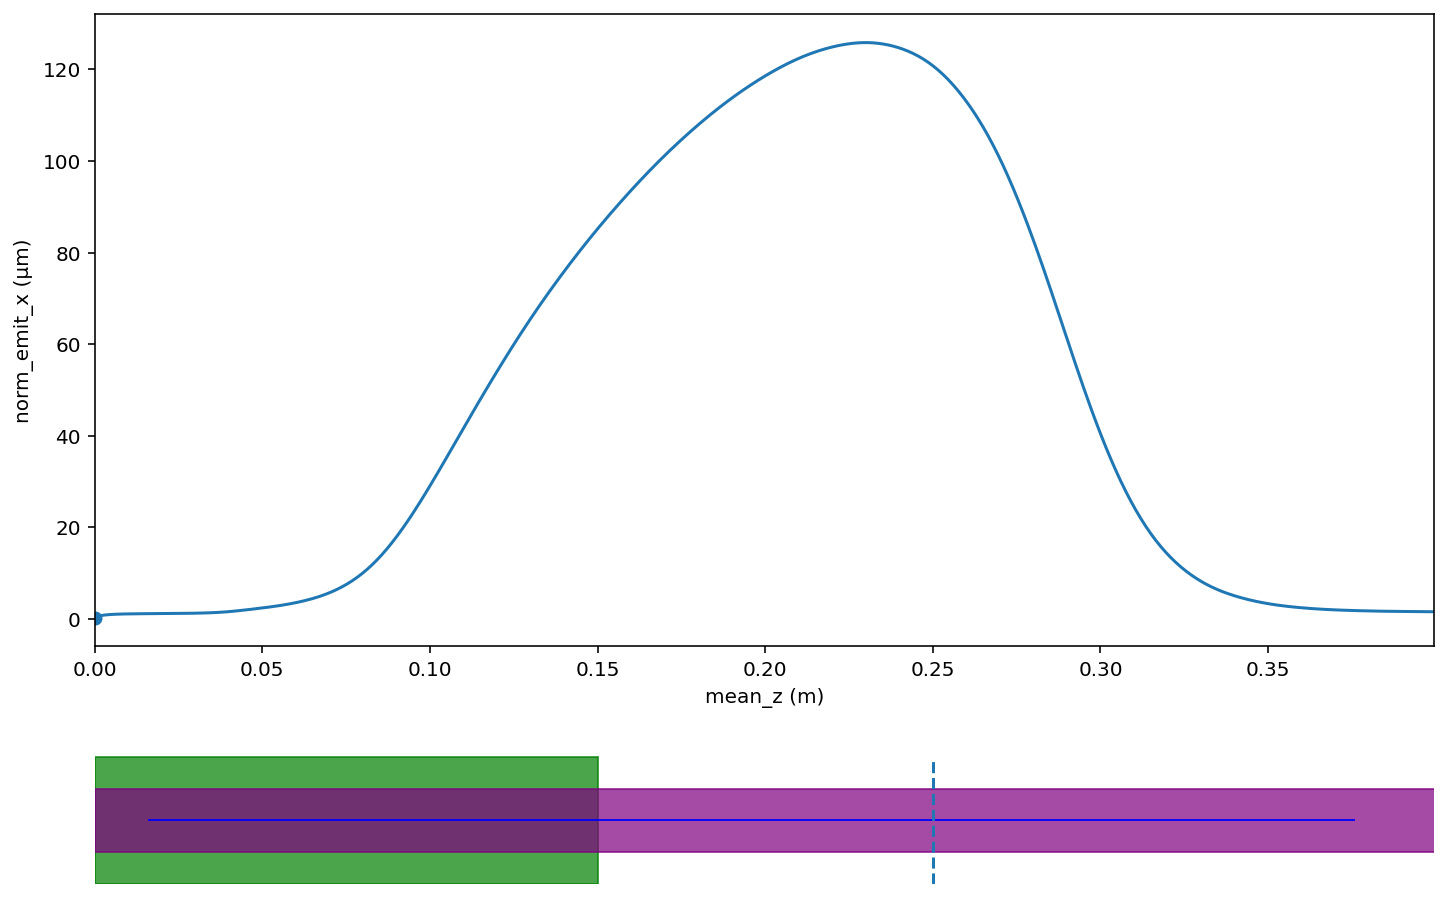

In [6]:
I0.plot('norm_emit_x')

# Scan `change_timestep_1:dt`

In [10]:
%%time
def set_dt(dt):
    I = Impact.from_yaml('ImpactT.yaml')
    I['change_timestep_1:dt'] = dt
  #  I.stop = 1
    I.run()
    return I
    
#set_dt(1e-12)

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 5.72 µs


# Parallel

In [11]:
from concurrent.futures import ProcessPoolExecutor

In [12]:
# Scan in powers of 2
dtlist = [100e-12 / 2**n for n in range(0,5) ] 
dtlist 

[1e-10, 5e-11, 2.5e-11, 1.25e-11, 6.25e-12]

In [13]:
%%time
with ProcessPoolExecutor(max_workers=1) as executor:
    results = list(executor.map(set_dt, dtlist))

CPU times: user 58.6 ms, sys: 77.5 ms, total: 136 ms
Wall time: 9min 5s


1e-10 527
5e-11 635
2.5e-11 852
1.25e-11 1286
6.25e-12 2154


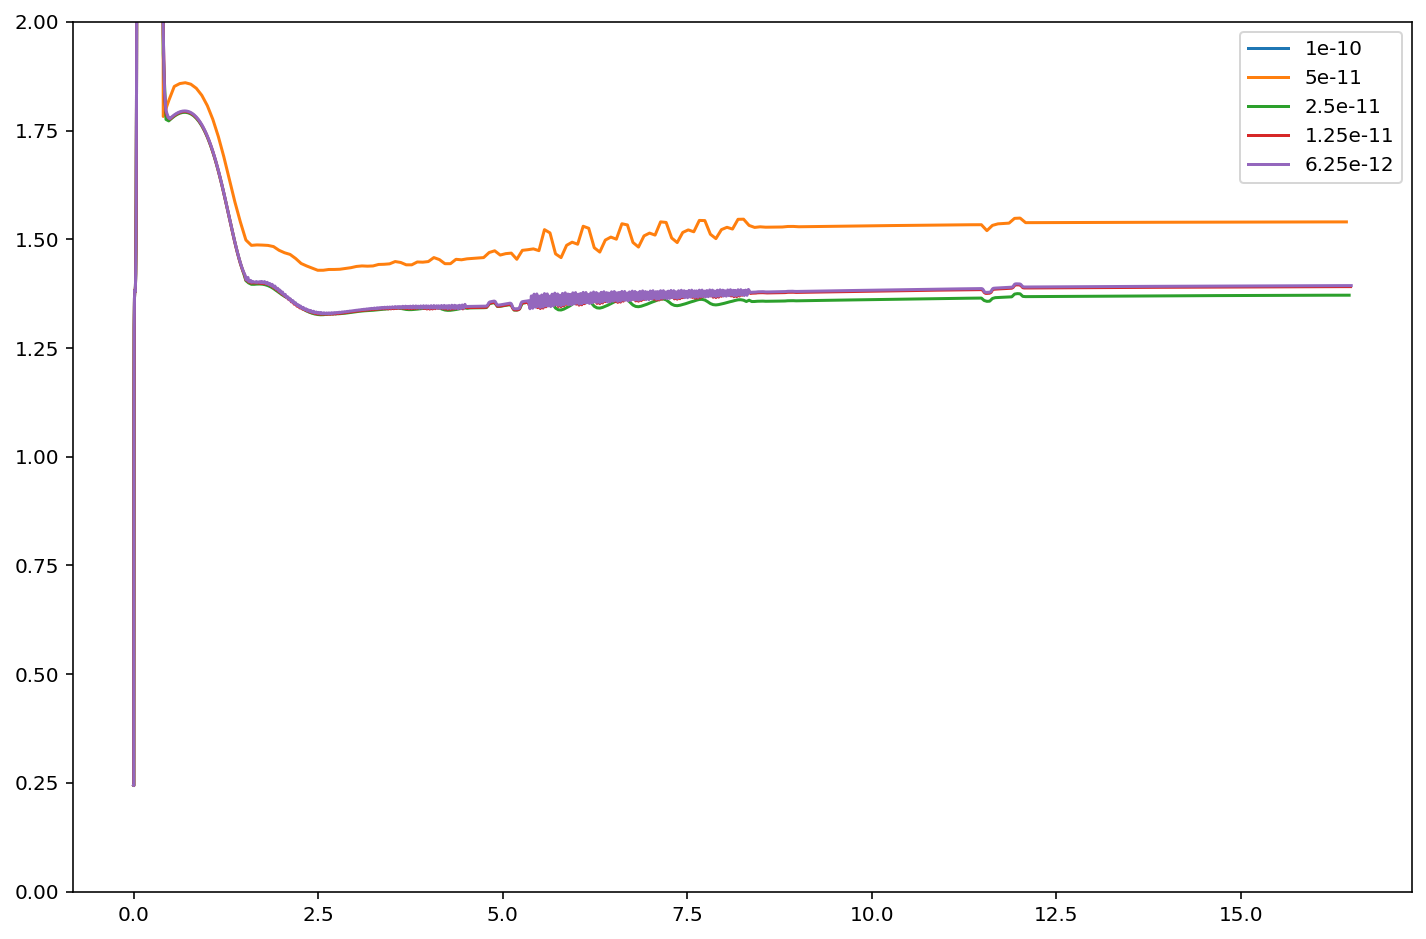

In [14]:
fig, ax = plt.subplots()

k1 = 'mean_z'
k2 = 'norm_emit_x'

f1 = 1
f2 = 1e6

for dt, I in zip(dtlist, results):
    
    x = I.stat(k1)*f1
    y = I.stat(k2)*f2
    print(dt, len(y))
    ax.plot(x, y, label=dt)
    
ax.set_ylim(0, 2)    
ax.legend()    
    

In [15]:
results[2].output['run_info']

{'error': False,
 'run_script': '/Users/chrisonian/Code/impact/impactT/bin/ImpactTv2.1_serial',
 'start_time': 1617389864.765554,
 'run_time': 93.77496695518494}